# Importing Essential Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Importing Dataset

In [2]:
car_data = pd.read_csv('used_cars.csv')
print("Shape:", car_data.shape)
print("\nColumns:", car_data.columns.tolist())
car_data.head()

Shape: (4009, 12)

Columns: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


# Checking Datatype

In [3]:
car_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [4]:
#for milage
car_data['milage']=car_data['milage'].replace([',', 'mi.'], ['', ''], regex=True).astype(int)

#For price
car_data['price']=car_data['price'].str.replace(r'[$,]', '', regex=True).astype(int)

# Datatype After Changing

In [5]:
car_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 376.0 KB


In [6]:
car_data.isnull().sum()


brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

# Finding Missing values

In [7]:
#For fule_type
car_data['fuel_type']=car_data['fuel_type'].fillna(value=car_data['fuel_type'].mode()[0])

#For accident
car_data['accident']=car_data['accident'].fillna(value=car_data['accident'].mode()[0])

#For clean_title
car_data['clean_title']=car_data['clean_title'].fillna('No')

# No Column Is Null 

In [8]:
car_data[['fuel_type', 'accident', 'clean_title']].isnull().sum()


fuel_type      0
accident       0
clean_title    0
dtype: int64

# Converting Clean_Column to True False

In [9]:
car_data['clean_title']=car_data['clean_title'].replace(['Yes', 'No'], [True, False]) #This will automatically convert the data type to boolean.

# Checking for Duplicates 

In [10]:
car_data.duplicated().unique()

array([False])

# Checking categorical Data

In [11]:
#Looking at the categorical values for each categorical data.
columns_to_check= ['fuel_type', 'transmission', 'ext_col', 'int_col', 'accident']
for i in columns_to_check:
    print(f"This is the list of column {i}\n {car_data[i].unique()}\n\n")

This is the list of column fuel_type
 <StringArray>
[ 'E85 Flex Fuel',       'Gasoline',         'Hybrid',         'Diesel',
 'Plug-In Hybrid',              '–',  'not supported']
Length: 7, dtype: str


This is the list of column transmission
 <StringArray>
[                                                     '6-Speed A/T',
                                                '8-Speed Automatic',
                                                        'Automatic',
                                                      '7-Speed A/T',
                                                                'F',
                                                              'A/T',
                                                      '8-Speed A/T',
                                   'Transmission w/Dual Shift Mode',
                                                '9-Speed Automatic',
                                                      '6-Speed M/T',
                                                   

# Changing fuel_Type to -

In [12]:
car_data['fuel_type']=car_data['fuel_type'].replace('–', 'not supported', regex=True)
car_data['fuel_type'].unique()

<StringArray>
[ 'E85 Flex Fuel',       'Gasoline',         'Hybrid',         'Diesel',
 'Plug-In Hybrid',  'not supported']
Length: 6, dtype: str

In [13]:
car_data= car_data[car_data['transmission']!= '–'] #excluding the cells where transmission = '–'

# Transmission must be string

In [14]:
car_data['transmission']= (car_data['transmission']
                           .str.lower().str.replace(r'[^a-z0-9\s]', '', regex=True) #includes only alphanumeric values.
                           .str.replace(r'\s+', ' ', regex=True) #Collapse spaces
                           .str.strip()) #Removes extra spacings

In [15]:
#Defining a function to fix the insonsistency of the transmission column.
def format_transmission(raw_data):
    if 'automatic' in raw_data or 'at' in raw_data:
        return 'Automatic'
    elif 'manual'in raw_data or 'mt' in raw_data:
        return 'Manual'
    elif 'cvtf' in raw_data or 'cvt' in raw_data:
        return 'CVT'
    else:
        return 'Other'

In [16]:
car_data['transmission']=car_data['transmission'].apply(format_transmission)
car_data['transmission'].unique()

<StringArray>
['Automatic', 'Other', 'Manual', 'CVT']
Length: 4, dtype: str

# Printing Car Data for Engine

In [17]:
car_data[car_data['engine']=='–'].head(10)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
130,Chrysler,Pacifica Touring,2017,87305,not supported,–,Automatic,Silver,Black,None reported,True,9000
257,Toyota,Land Cruiser Base,1993,231500,not supported,–,Automatic,White,Gray,None reported,True,29500
338,Mazda,Mazda3 s Grand Touring,2016,85000,not supported,–,Automatic,Black,Black,At least 1 accident or damage reported,True,18500
491,Chrysler,Pacifica Touring,2017,63000,not supported,–,Automatic,White,Beige,None reported,True,20000
692,Honda,Civic EX,1993,58981,not supported,–,Automatic,White,Beige,None reported,True,9599
923,Dodge,Challenger R/T,2010,100100,not supported,–,Other,Purple,Black,None reported,True,17000
995,Dodge,Challenger R/T Scat Pack,2019,43000,not supported,–,Manual,Green,Black,None reported,True,50000
1063,Mazda,Mazda6 i Grand Touring,2016,83100,not supported,–,Automatic,White,White,None reported,True,17800
1083,Dodge,Challenger R/T,2010,73000,not supported,–,Automatic,Black,Black,None reported,True,17500
1084,Chevrolet,Sonic LT,2013,110000,not supported,–,Automatic,Gray,Black,None reported,True,7500


In [18]:
car_data['engine']=car_data['engine'].str.replace('–', 'Electric')

In [19]:
car_data.select_dtypes(include=int).describe()


,model_year,milage,price
count,4005.000000,4005.000000,4.005000e+03
mean,2015.523096,64768.166292,4.436553e+04
std,6.071196,52296.888588,7.823844e+04
min,1992.000000,100.000000,2.000000e+03
25%,2012.000000,23097.000000,1.710000e+04
50%,2017.000000,53000.000000,3.100000e+04
75%,2020.000000,94155.000000,4.990000e+04
max,2024.000000,405000.000000,2.954083e+06


# Quantile For Bigger and smaller Values

In [20]:
numeric_columns = ['milage', 'price'] 
for column in numeric_columns: 
    Q1 = car_data[column].quantile(0.25) 
    Q3 = car_data[column].quantile(0.75) 
    IQR = Q3 - Q1 
    lower_whisker = Q1 - 2 * IQR 
    upper_whisker = Q3 + 2 * IQR 
    car_data= car_data[(car_data[column]>=lower_whisker) & (car_data[column]<=upper_whisker)]

car_data.reset_index(inplace=True, drop=True)
car_data.select_dtypes(include=int).describe()

,model_year,milage,price
count,3788.000000,3788.000000,3788.000000
mean,2015.393347,66026.504224,34606.690074
std,6.043630,49241.020851,22734.131776
min,1992.000000,100.000000,2000.000000
25%,2012.000000,25909.000000,16900.000000
50%,2017.000000,55483.500000,29998.000000
75%,2020.000000,95462.500000,46500.000000
max,2024.000000,235000.000000,114900.000000


In [21]:
car_data.select_dtypes(include='int').describe()


,model_year,milage,price
count,3788.000000,3788.000000,3788.000000
mean,2015.393347,66026.504224,34606.690074
std,6.043630,49241.020851,22734.131776
min,1992.000000,100.000000,2000.000000
25%,2012.000000,25909.000000,16900.000000
50%,2017.000000,55483.500000,29998.000000
75%,2020.000000,95462.500000,46500.000000
max,2024.000000,235000.000000,114900.000000


In [22]:
car_data.select_dtypes(include='object').describe()


,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
count,3788,3788,3788,3788,3788,3788,3788,3788,3788
unique,55,1797,6,1065,4,282,136,2,2
top,Ford,M3 Base,Gasoline,Electric,Automatic,Black,Black,None reported,True
freq,377,30,3283,60,2980,857,1933,2820,3251


In [23]:
correlation=car_data.select_dtypes(include='int').corr()
correlation

,model_year,milage,price
model_year,1.000000,-0.616794,0.573352
milage,-0.616794,1.000000,-0.640691
price,0.573352,-0.640691,1.000000


# DATA VISUALIZATION

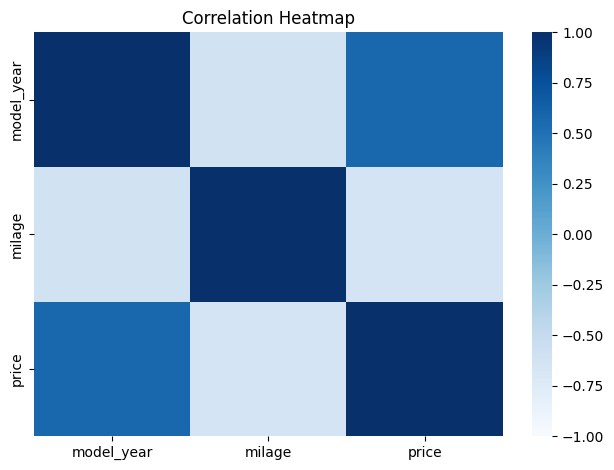

In [24]:
plt.Figure(figsize=(10,8))
sns.heatmap(correlation, vmin=-1, vmax=1, cmap='Blues')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

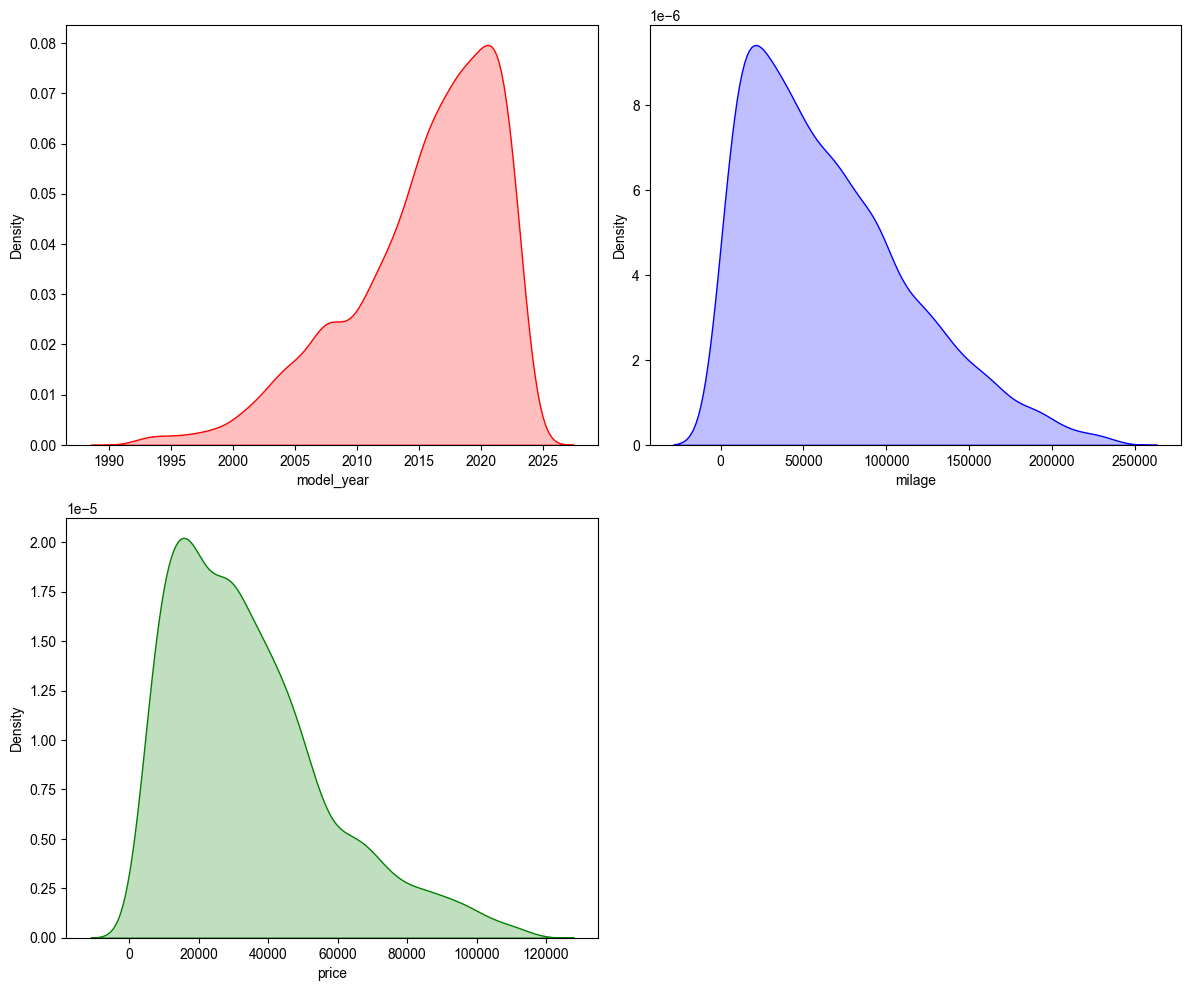

In [25]:
n_rows= 2
numeric_columns= car_data.select_dtypes(include=int).columns.to_list()
n_columns= int(np.ceil(len(numeric_columns)/n_rows))
colors= ['red', 'blue', 'green']

plt.figure(figsize=(12,10))
for idx, column in enumerate(car_data[numeric_columns],1):
    plt.subplot(n_rows, n_columns, idx)
    #sns.histplot(data=Car_data, x=column, bins=50, kde=True)
    sns.kdeplot(data=car_data, x= column, fill=colors[idx-1], color=colors[idx-1])
sns.set_theme('paper')
plt.tight_layout()

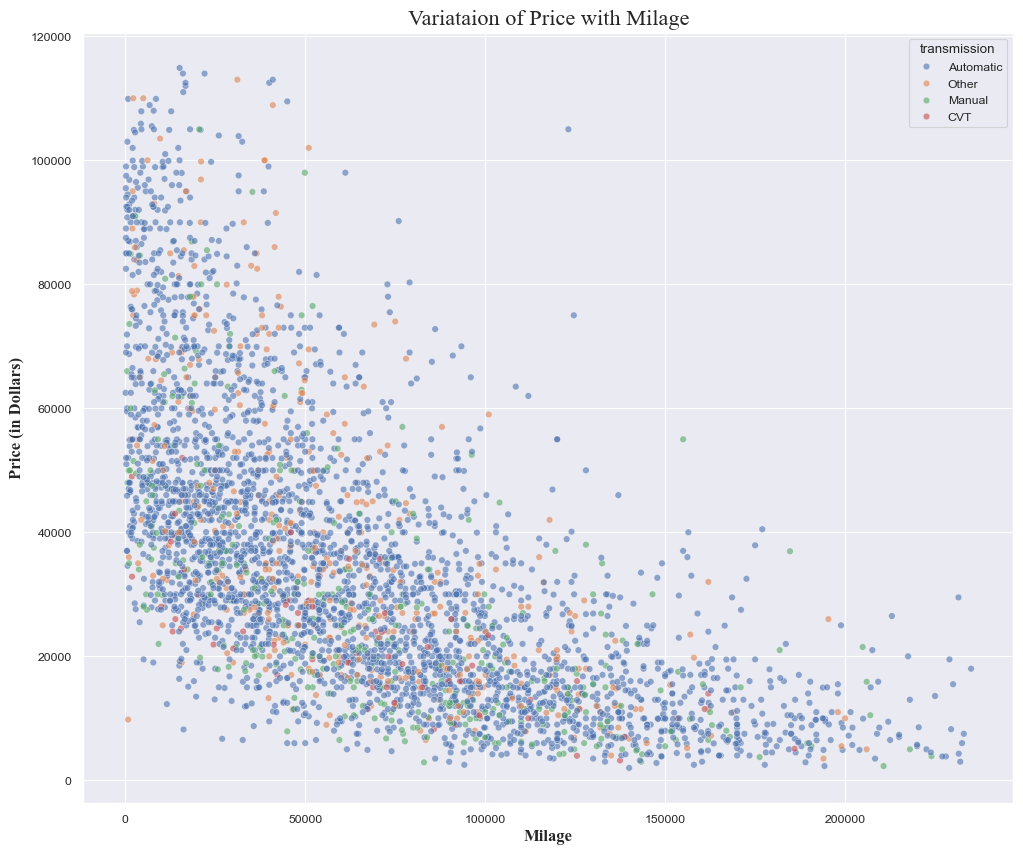

In [26]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=car_data, x='milage', y='price', hue='transmission', alpha=0.6)
plt.xlabel('Milage', fontdict={'family': 'Times New Roman', 'size':12, 'fontweight':'bold'})
plt.ylabel('Price (in Dollars)', fontdict={'family': 'Times New Roman', 'size':12, 'fontweight':'bold'})
plt.title('Variataion of Price with Milage', fontdict={'family': 'Times New Roman','size': 16})
sns.set_theme('paper')
plt.show()

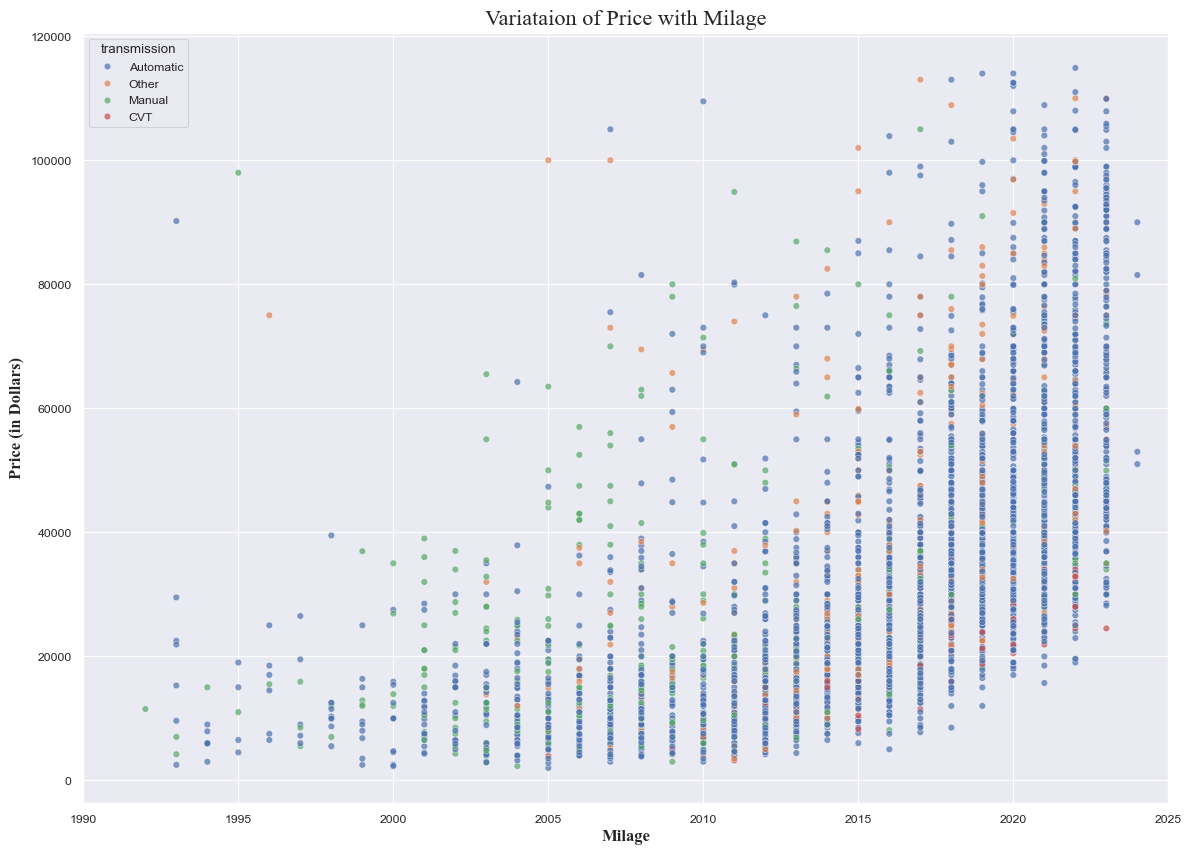

In [27]:
plt.figure(figsize=(14,10))
sns.scatterplot(data=car_data, x='model_year', y='price', hue='transmission', alpha=0.7)
plt.xlabel('Milage', fontdict={'family': 'Times New Roman', 'size':12, 'fontweight':'bold'})
plt.ylabel('Price (in Dollars)', fontdict={'family': 'Times New Roman', 'size':12, 'fontweight':'bold'})
plt.title('Variataion of Price with Milage', fontdict={'family': 'Times New Roman','size': 16})
plt.xlim(left=1990, right=2025)
sns.set_theme('notebook')
plt.show()

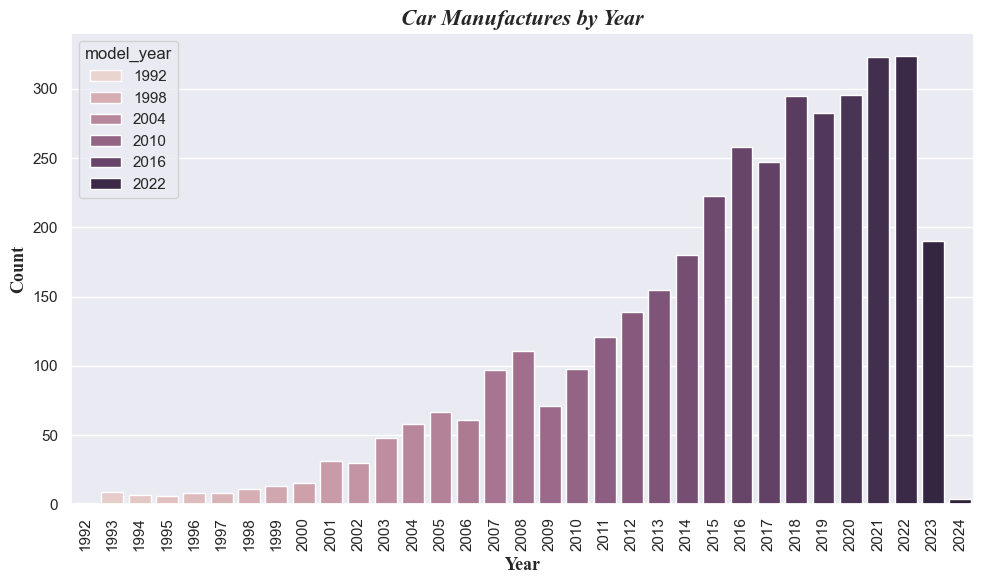

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(data=car_data, x='model_year', width=0.8, hue='model_year')
plt.xticks(rotation=90)
plt.xlabel('Year', fontdict={'family': 'Times New Roman', 'size':13, 'weight': 'bold'})
plt.ylabel('Count', fontdict={'family': 'Times New Roman', 'size':13, 'weight': 'bold'})
plt.title('Car Manufactures by Year', fontdict={'family': 'Times New Roman', 'style': 'oblique', 'size':16, 'weight': 'bold'})
sns.set_style('darkgrid')
sns.set_theme('notebook')
plt.tight_layout()
plt.show()

In [30]:
time_series_data= pd.DataFrame(car_data.groupby(by=['model_year'])['price'].mean(), columns=['price'])

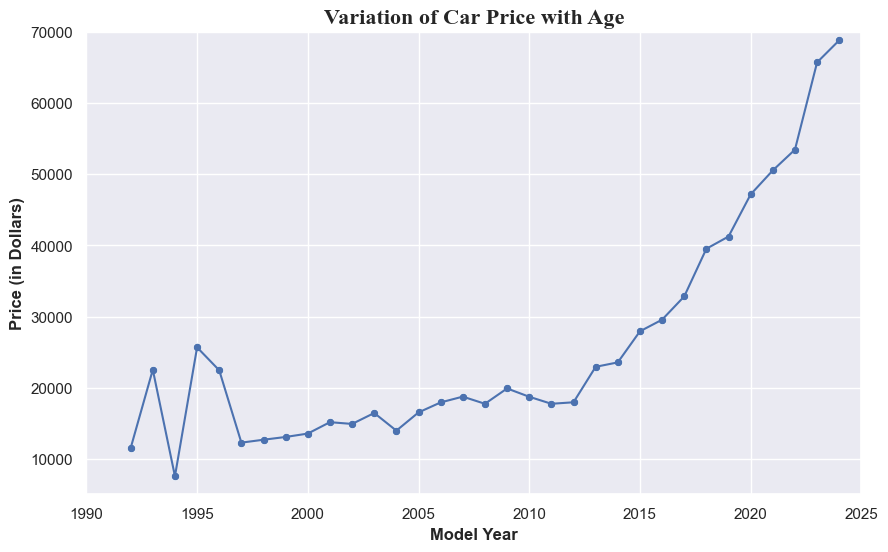

In [31]:
#Plotting
plt.figure(figsize=(10,6))
sns.lineplot(data=time_series_data, x='model_year', y='price')
sns.scatterplot(data=time_series_data, x='model_year', y='price')
plt.title('Variation of Car Price with Age', fontdict={'family': 'Times New Roman','size': 16, 'fontweight': 'bold'})
plt.xlabel('Model Year', fontdict={'fontweight':'bold'})
plt.ylabel('Price (in Dollars)', fontdict={'fontweight':'bold'})
sns.set_theme('notebook')
plt.xlim(left=1990, right=2025)
plt.ylim(5000,70000)
plt.show()

In [32]:
accident_car_data= pd.DataFrame(car_data.groupby(by=['model_year', 'accident'])['price'].mean(), columns=['price'])

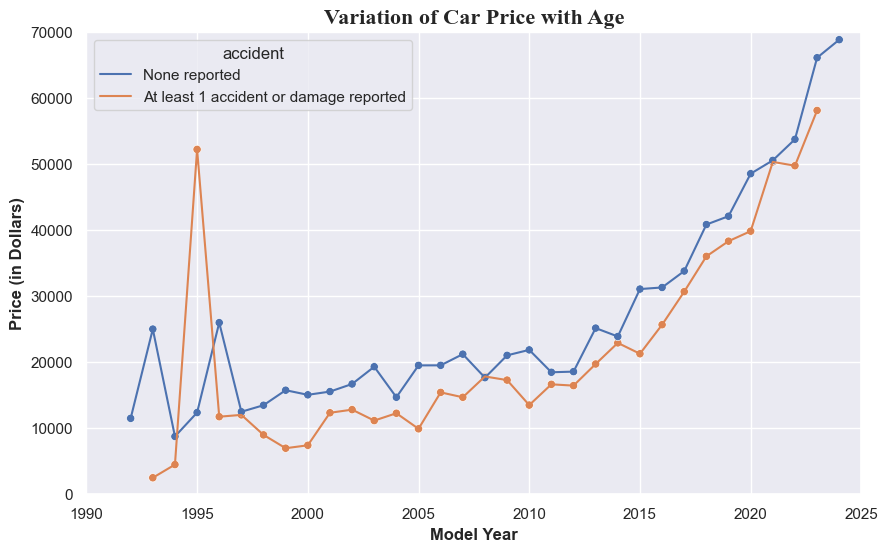

In [33]:
#Plotting
plt.figure(figsize=(10,6))
sns.lineplot(data=accident_car_data, x='model_year', y='price', hue='accident')
sns.scatterplot(data=accident_car_data, x='model_year', y='price', hue='accident', legend=False)
plt.title('Variation of Car Price with Age', fontdict={'family': 'Times New Roman','size': 16, 'fontweight': 'bold'})
plt.xlabel('Model Year', fontdict={'fontweight':'bold'})
plt.ylabel('Price (in Dollars)', fontdict={'fontweight':'bold'})
sns.set_theme('notebook')
plt.xlim(left=1990, right=2025)
plt.ylim(0,70000)
plt.show()

In [34]:
car_data.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,At least 1 accident or damage reported,True,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,True,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,False,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,None reported,True,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,Glacier White Metallic,Black,None reported,False,34999


In [35]:
car_data[(car_data['model_year']==1995) & (car_data['accident']!= 'None reported')]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
1215,Chevrolet,1500 Cheyenne Extended Cab,1995,120000,not supported,Electric,Automatic,White,Brown,At least 1 accident or damage reported,True,6500
2680,Porsche,911 Carrera,1995,49900,not supported,Electric,Manual,Silver,Gray,At least 1 accident or damage reported,True,97993


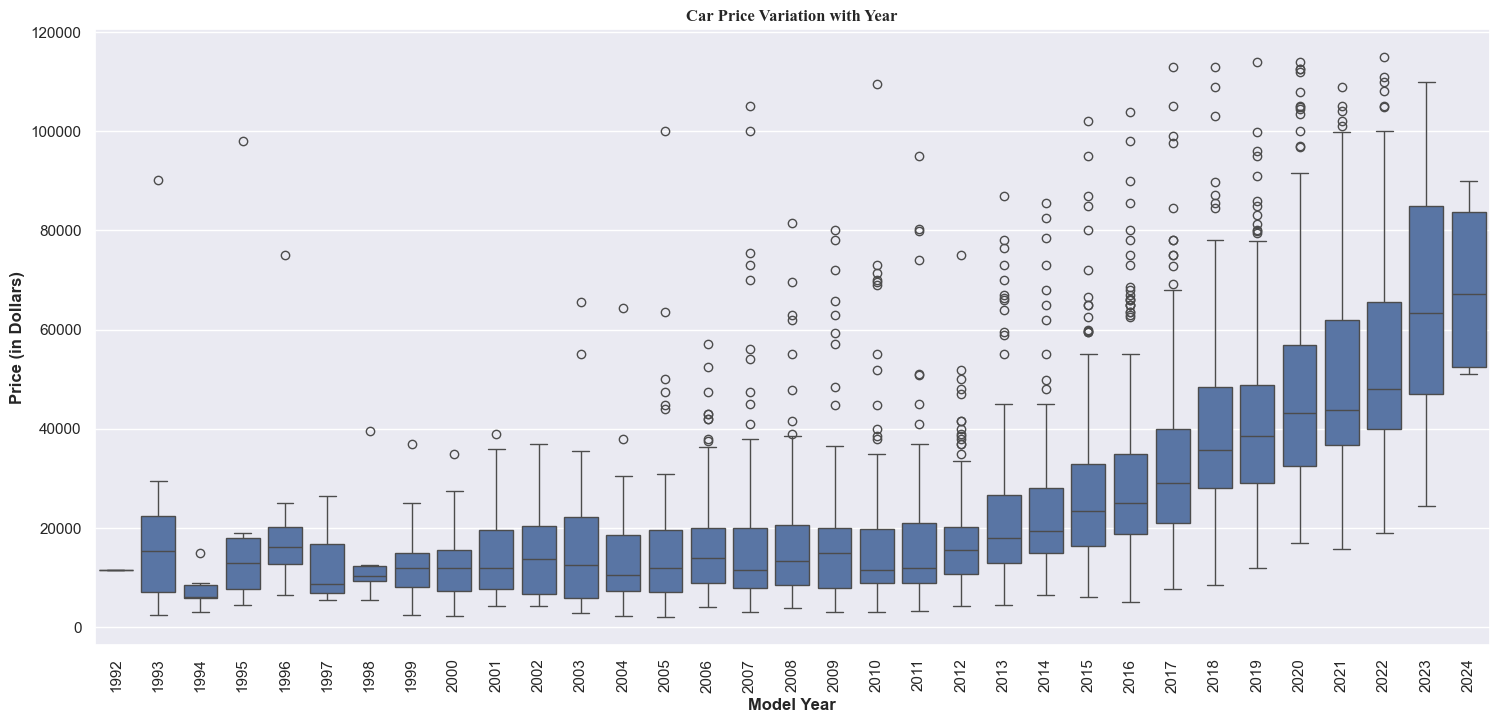

In [36]:
#Box plot:
plt.figure(figsize=(18,8))
sns.boxplot(data=car_data, x='model_year', y='price')
plt.xticks(rotation=90)
plt.xlabel('Model Year', fontdict={'size': 12, 'fontweight': 'bold'})
plt.ylabel('Price (in Dollars)', fontdict={'size': 12, 'fontweight': 'bold'})
plt.title('Car Price Variation with Year', fontdict={'family': 'Times New Roman','size': 12, 'fontweight': 'bold'})
plt.show()

In [39]:
# Strong the brands and models of the car separately
car_models=car_data['model']
car_brands= car_data['brand']

In [40]:
# Defining Average Brand Price
brand_average_price=car_data.groupby(by=['brand'])['price'].mean().reset_index()
car_data=car_data.merge(brand_average_price, how='left', on=['brand'])
car_data.rename(columns={'price_x': 'price', 'price_y': 'average_brand_price'}, inplace=True)


In [41]:
#Creating the column horse_power
car_data['horse_power']=car_data['engine'].str.extract(r'(\d+(?:\.\d+)?)\s*HP').astype(float)

In [42]:
#Creating a new column engine_capacity
car_data['engine_capacity']=car_data['engine'].str.extract(r'(\d+(?:\.\d)?)\s*L').astype(float)

In [43]:
# Creating a new column Cylinders
car_data['cylinder_number']=car_data['engine'].str.extract(r'(\d+(?:\.\d)?)\s*Cylinder')
car_data['cylinder_number']= car_data['cylinder_number'].replace(np.nan, 0)
car_data['cylinder_number']=car_data['cylinder_number'].astype(int)

In [44]:
car_data['age']=2025-car_data['model_year']

#Dropiing the features engine and model_year
car_data= car_data.drop(columns=['model_year', 'engine'])

In [45]:
car_data[['horse_power', 'engine_capacity', 'cylinder_number']].describe()


,horse_power,engine_capacity,cylinder_number
count,3067.000000,3577.000000,3788.000000
mean,325.837952,3.768773,4.786167
std,117.373291,3.175346,2.963148
min,70.000000,1.000000,0.000000
25%,245.500000,2.500000,4.000000
50%,308.000000,3.500000,6.000000
75%,395.000000,4.600000,8.000000
max,1020.000000,75.000000,12.000000


In [46]:
car_data.loc[car_data['engine_capacity'] > 10, 'engine_capacity'] = car_data.loc[car_data['engine_capacity'] > 10, 'engine_capacity'] / 10

In [47]:
car_data_copy=car_data.copy()           #For future use in Clustering


In [48]:
car_data


,brand,model,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,average_brand_price,horse_power,engine_capacity,cylinder_number,age
0,Ford,Utility Police Interceptor Base,51000,E85 Flex Fuel,Automatic,Black,Black,At least 1 accident or damage reported,True,10300,35365.472149,300.0,3.7,6,12
1,Hyundai,Palisade SEL,34742,Gasoline,Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,True,38005,18946.875000,NaN,3.8,0,4
2,Lexus,RX 350 RX 350,22372,Gasoline,Automatic,Blue,Black,None reported,False,54598,33624.076433,NaN,3.5,0,3
3,INFINITI,Q50 Hybrid Sport,88900,Hybrid,Automatic,Black,Black,None reported,True,15500,22927.644068,354.0,3.5,6,10
4,Audi,Q3 45 S line Premium Plus,9835,Gasoline,Automatic,Glacier White Metallic,Black,None reported,False,34999,35455.656250,NaN,2.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,Mercedes-Benz,E-Class E 300 4MATIC,53705,Gasoline,Automatic,Black,Black,At least 1 accident or damage reported,True,25900,39732.398601,241.0,2.0,4,7
3784,Audi,S4 3.0T Premium Plus,10900,Gasoline,Other,Black,Black,None reported,True,53900,35455.656250,349.0,3.0,6,3
3785,Porsche,Taycan,2116,Gasoline,Automatic,Black,Black,None reported,False,90998,52842.967532,NaN,NaN,0,3
3786,Ford,F-150 Raptor,33000,Gasoline,Automatic,Blue,Black,None reported,True,62999,35365.472149,450.0,3.5,6,5


In [49]:
#Dropping the unwanted columns
car_data= car_data.drop(columns=['model', 'ext_col', 'int_col', 'brand'])

In [50]:
car_data


,milage,fuel_type,transmission,accident,clean_title,price,average_brand_price,horse_power,engine_capacity,cylinder_number,age
0,51000,E85 Flex Fuel,Automatic,At least 1 accident or damage reported,True,10300,35365.472149,300.0,3.7,6,12
1,34742,Gasoline,Automatic,At least 1 accident or damage reported,True,38005,18946.875000,NaN,3.8,0,4
2,22372,Gasoline,Automatic,None reported,False,54598,33624.076433,NaN,3.5,0,3
3,88900,Hybrid,Automatic,None reported,True,15500,22927.644068,354.0,3.5,6,10
4,9835,Gasoline,Automatic,None reported,False,34999,35455.656250,NaN,2.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...
3783,53705,Gasoline,Automatic,At least 1 accident or damage reported,True,25900,39732.398601,241.0,2.0,4,7
3784,10900,Gasoline,Other,None reported,True,53900,35455.656250,349.0,3.0,6,3
3785,2116,Gasoline,Automatic,None reported,False,90998,52842.967532,NaN,NaN,0,3
3786,33000,Gasoline,Automatic,None reported,True,62999,35365.472149,450.0,3.5,6,5


# Data spliting

In [53]:
X= car_data.drop(columns='price')
y=car_data['price']

#Test Train split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3030, 10)
Test size: (758, 10)


In [54]:
# SageMaker XGBoost expects: target column FIRST, no header
train_data = pd.concat([y_train.reset_index(drop=True), 
                         X_train.reset_index(drop=True)], axis=1)
test_data  = pd.concat([y_test.reset_index(drop=True),  
                         X_test.reset_index(drop=True)],  axis=1)

# Save without header and without index (SageMaker requirement)
train_data.to_csv('train.csv', header=False, index=False)
test_data.to_csv('test.csv',  header=False, index=False)

print("✅ train.csv and test.csv saved — ready for SageMaker!")



✅ train.csv and test.csv saved — ready for SageMaker!


In [ ]:
# Data Ready for the Sagemagemaker in 

In [57]:
train_data.to_csv('train.csv', header=False, index=False)
test_data.to_csv('test.csv',  header=False, index=False)
